In [68]:
import pandas as pd
import numpy as np

In [78]:

#Interpolate the data to get the daily values for each year
#This will give the 366 values for the daily LAI data (with DOYs 1-366)

def process_modisLAI(LAI_csv_path):

    """
    Process 8-day MODIS LAI data to long-term annual average LAI cycle
    The data is downloaded from Google Earth Engine as timeseries for a region corresponding to a specific vegetation type.
    Here the data is for a deciduous broadleaf forest in Europe

    Input:
    LAI_csv_path: str, path to the CSV file containing MODIS LAI data

    Output:
    modisLAI_grouped: DataFrame, processed MODIS LAI data with 8-day averaged across many years

    """
    #
    modisLAI = pd.read_csv(LAI_csv_path)
    #the date column is in the format e.g. 'Jul 4, 2002' and needs to be converted to datetime
    #convert the date column to datetime. e.g Jul 4, 2002 is 2002-07-04
    #rename columns to time and Lai_500m
    modisLAI.columns = ['time', 'Lai_500m']

    modisLAI['date'] = pd.to_datetime(modisLAI['time'], format='%b %d, %Y')

    #group the data by day of year (doy) and calculate the mean for each doy
    #This will give the 45 values for the 8-day LAI data (with DOYs 1-361)
    modisLAI['doy'] = modisLAI['date'].dt.dayofyear

    #The LAI need to be rescaled by 0.1 to get true LAI values
    modisLAI_grouped = modisLAI.groupby('doy').mean(numeric_only=True).reset_index()

    modisLAI_grouped['Lai_500m'] = modisLAI_grouped['Lai_500m'] * 0.1

    #Now interpolate the data to get the daily values for each year
    #This will give the 366 values for the daily LAI data (with DOYs 1-366)
    #First append a value corresponding to the 366th day of the year. 
    # We can take it to equal the LAI value of the 1st day of the next year.

    #select the first column of the dataframe and append it to the end of the dataframe
    LAI_366 = pd.DataFrame({'doy':366, 'Lai_500m':modisLAI_grouped['Lai_500m'][0]}, index=[0])

    #append the new row to the end of the dataframe
    modisLAI_grouped = pd.concat([modisLAI_grouped, LAI_366], ignore_index=True)

    # make it into a Series indexed by doy
    lai_cycle = pd.Series(
        data = modisLAI_grouped['Lai_500m'].values,
        index = modisLAI_grouped['doy']
)

    # reindex to cover 1–366 and linearly fill in between
    lai_annual_cycle = lai_cycle.reindex(np.arange(1, 367)).interpolate(method='linear')

    return lai_annual_cycle

    # ── 2) Function to grab any date range
def get_daily_lai(start_date, end_date, LAIcycle):
    """
    Returns a pandas Series of daily LAI between start_date and end_date,
    by mapping each day-of-year into the 1–366 climatology cycle.
    """
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    doys = dates.dayofyear  # 1–365 or 1–366 on leap years
    daily_vals = LAIcycle.loc[doys].values
    return pd.Series(daily_vals, index=dates, name='Lai_500m')


In [ ]:
#Execute
annual_lai_cycle = process_modisLAI('./data/modisLAI_2002_2020.csv')
dailyLAI = get_daily_lai('2002-01-01', '2020-12-31', annual_lai_cycle)


<Axes: title={'center': 'LAI Daily Cycle'}, ylabel='LAI (m2/m2)'>

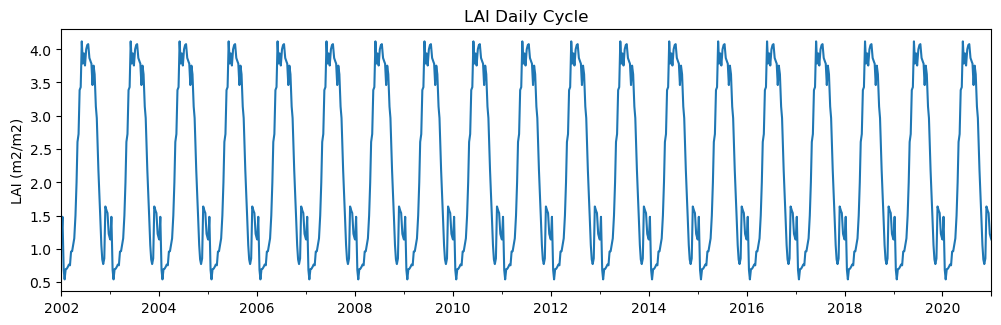

In [85]:
dailyLAI.plot(figsize=(12, 3.4), title='LAI Daily Cycle', ylabel='LAI (m2/m2)')

### Interception from VIC model